# PHASE TWO PROJECT

##  A DATA-DRIVEN LOOK AT MOVIE PROFITS

![Aviation accidents trend and factors](Images/OIP.jpg)

For this project I will be using data set obtained in the **'data_set.ipynb'** notebook and stored in the **movies.csv** in the Data folder.

This data was obtained by joining cleaning and formarting data from the **im.db** file and **bom.movie_gross.csv** file

## OBJECTIVES

I will use the data to:
- Analyze movie profitability trends by examining the relationship between features like runtime, rating, genre, and revenue
- Identify key factors that contribute to a movies commercial success
- Explore temporal trends in movie performance
- Provide business insights into which genres or studios consistently produce high-grossing movies

### Objective 1: Analyze movie profitability trends by examining the relationship between features like runtime, rating, genre, and revenue

In [102]:
#Importing laibraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [103]:
#Loading data from movie.csv
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4


In [104]:
#1st I need to create a new column called profits which is a 
#total-sumation(foreign + domestic gross) of both domestic and foreign gross revenue generated by every movie

df['total_gross'] = df['domestic_gross'] +df['foreign_gross']
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4,652301019.4


### Total gross distribution

This will show us how the total gross generated accross the data set is distributed

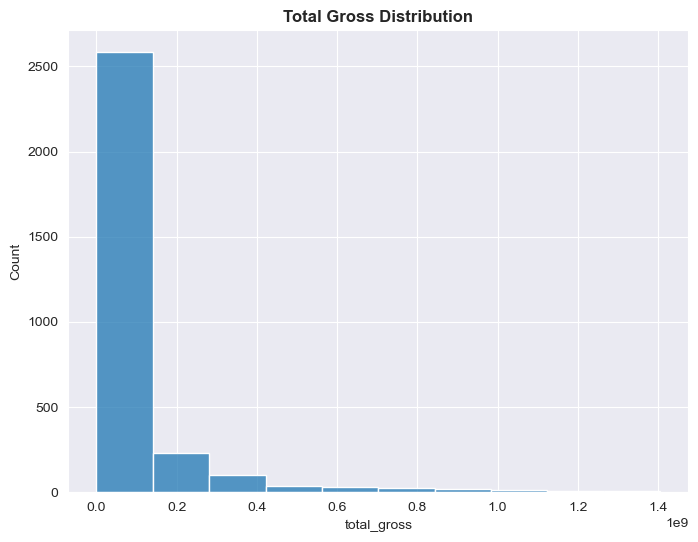

In [107]:
plt.figure(figsize = (8, 6))

sns.histplot(data = df, x = 'total_gross', bins = 10)
plt.title('Total Gross Distribution', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

#### 1. Runtime vs total_gross

Here we will look at how runtime affects the total gross a movie makes

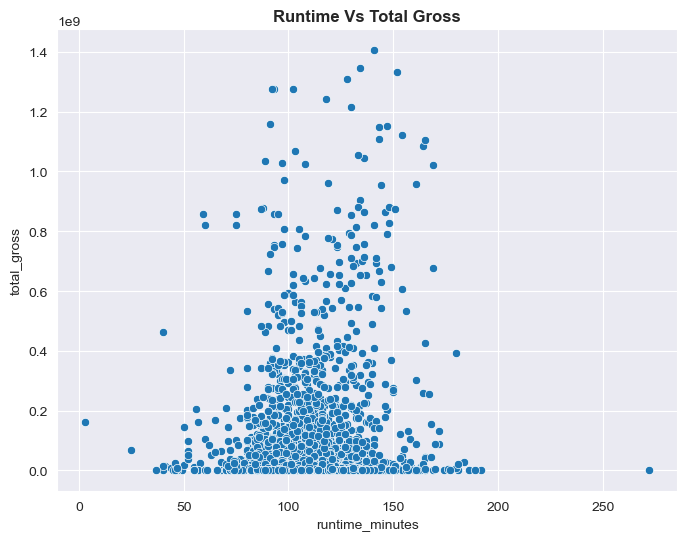

In [110]:
#create a figure to plot our scatter plot
plt.figure(figsize = (8, 6))

#PLot runtime vs total gross
sns.scatterplot(data = df, x = df['runtime_minutes'], y = df['total_gross'])
plt.title('Runtime Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

#### 2. Average Rating vs. Total Gross

Now lets look at how ratings impact total gross

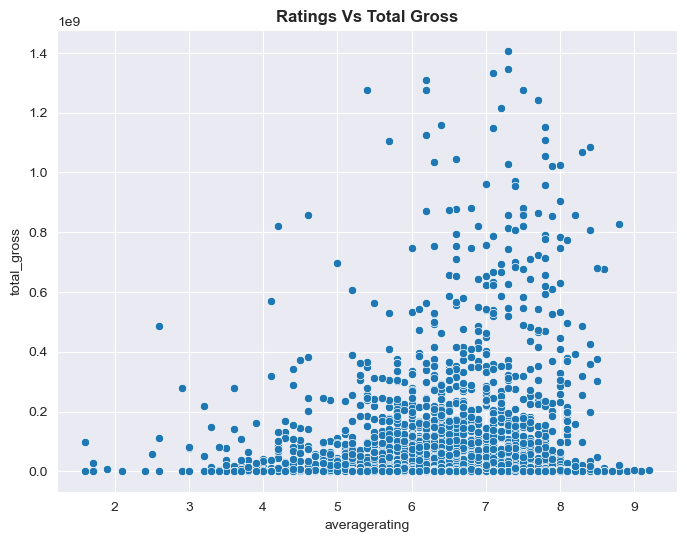

In [113]:
#Create a figure for our plot
plt.figure(figsize = (8, 6))

#plot ratings vs total gross
sns.scatterplot(data = df, x = df['averagerating'], y = df['total_gross'])
plt.title('Ratings Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

#### 3. Number of Votes vs. Total Gross

These will show us how popularity impacts movie sales

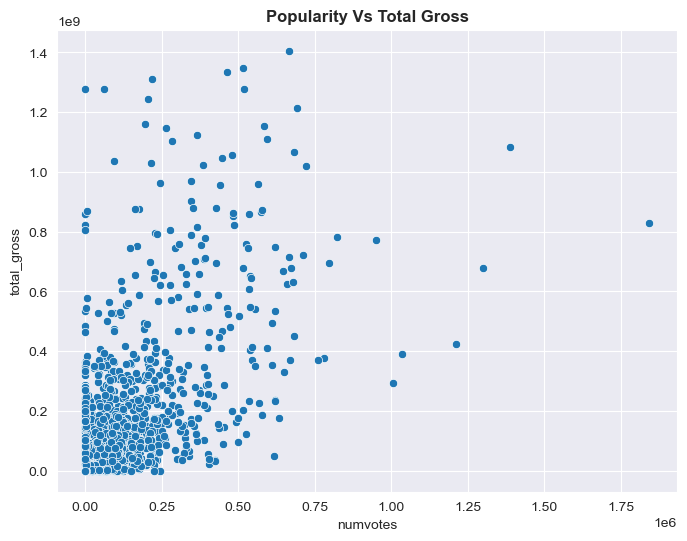

In [116]:
plt.figure(figsize = (8, 6))

sns.scatterplot(data = df, x = df['numvotes'], y = df['total_gross'])
plt.title('Popularity Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

#### 4. Correlation of ratings, popularity and runtime to gross total

This will help us identify whch features have strong and negative correlation to the gross total

In [119]:
df[['runtime_minutes', 'numvotes', 'averagerating', 'total_gross']].corr()

,runtime_minutes,numvotes,averagerating,total_gross
runtime_minutes,1.000000,0.260339,0.145239,0.151571
numvotes,0.260339,1.000000,0.283495,0.656075
averagerating,0.145239,0.283495,1.000000,0.121542
total_gross,0.151571,0.656075,0.121542,1.000000


**From the above we can see that popularity('numvotes') has the highest positive correlation meaning the popularity boosts revenue generated**

### Objective 2: Identify key factors that contribute to a movies commercial success

This part we will look more closely at the genres

The questions we are going to answer are:
- Which genres are most profitable
- Do highly rated genres earn more
- Are popular genres also the most profitable

But scince our genre column contains a list of all the diffrent genres a single movie belongs to, we need to use **.explode()** to split every genre into a row on its own then **group by** genre for analysis

### 1. Expanding the genre column using explode() function

In [152]:
#Exploding the genre column
df['genres'] = df['genres'].str.strip("[]'\" ")
df = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df.head(10)

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,Action,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Crime,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Drama,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Romance,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,Adventure,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Comedy,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Drama,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,Action,114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0


### 2. Group by Genre then summarize the total gross by genre

Now we summarize profitability and popularity per genre

In [158]:
#Grouping by genres and summarizing by profitability and popularity
df_summary = df.groupby('genres').agg(
    avg_total_gross=('total_gross', 'mean'),
    median_total_gross=('total_gross', 'median'),
    avg_rating=('averagerating', 'mean'),
    avg_votes=('numvotes', 'mean'),
    count=('genres', 'count')
).sort_values(by='avg_total_gross', ascending=False)

df_summary

,avg_total_gross,median_total_gross,avg_rating,avg_votes,count
genres,,,,,
Sci-Fi,2.842401e+08,132450000.0,6.455147,245906.779412,136
Adventure,2.732155e+08,150050000.0,6.491964,158102.066964,448
Animation,2.525529e+08,119400000.0,6.721519,87334.360759,158
Fantasy,1.696389e+08,52300000.0,6.258857,110138.342857,175
Action,1.653266e+08,54400000.0,6.293435,123295.346565,655
Family,1.297424e+08,47100000.0,6.220168,54729.033613,119
Comedy,8.274729e+07,13100000.0,6.256092,59249.539916,952
Sport,7.978087e+07,12100000.0,6.915094,52877.226415,53
Thriller,7.781469e+07,14100000.0,6.177232,79502.198661,448


### 3. Visualizing Factors/Insights 

After our data is summarized we can now visualize it to get a visual representation of the key factors that contribute to a movies commercial success 

#### Top 10 genres by average total gross

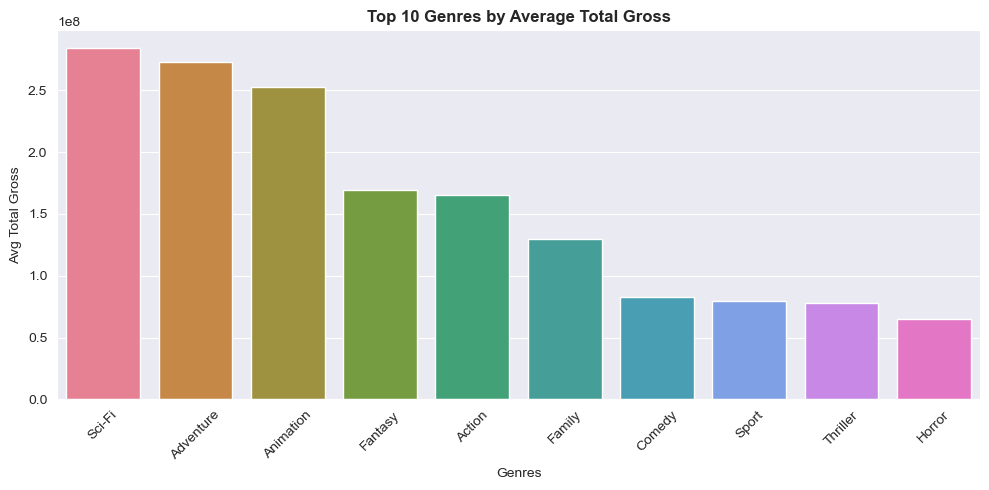

In [185]:
#Get the most profitable genres
top_genres = df_summary.head(10)
top_genres = top_genres.reset_index()

#Plot a bar graph to represent them
plt.figure(figsize = (10, 5))

#making each bar have a ditinct color
palette = sns.color_palette("husl", len(top_genres))

sns.barplot(data  = top_genres, x = 'genres', y = 'avg_total_gross', hue='genres', palette = palette)
plt.title('Top 10 Genres by Average Total Gross', weight = 'bold')
plt.xlabel('Genres')
plt.ylabel('Avg Total Gross')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Ratings and popularity vs Gross per Genre

Now we take a look at how ratings against gross per genre

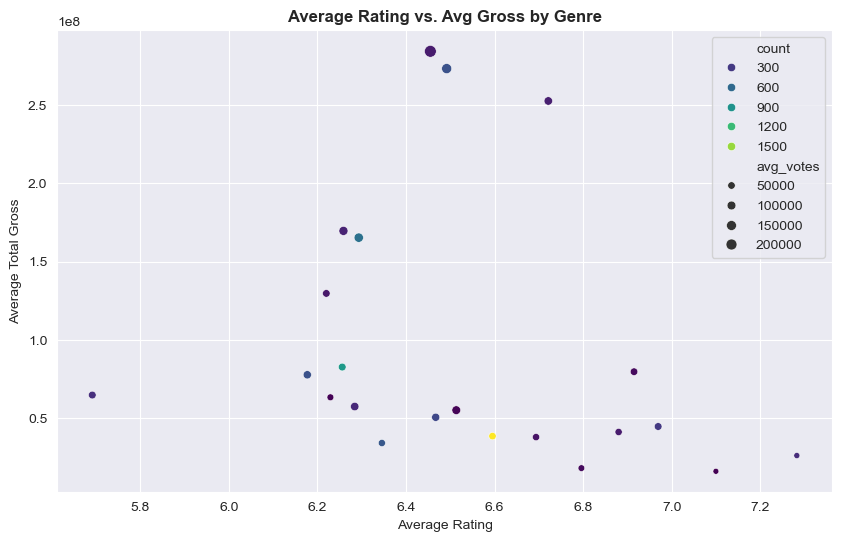

In [199]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_summary, x='avg_rating', y='avg_total_gross', size='avg_votes', hue='count', palette='viridis', legend=True)
plt.title('Average Rating vs. Avg Gross by Genre', weight = 'bold')
plt.xlabel('Average Rating')
plt.ylabel('Average Total Gross')
plt.grid(True)
plt.show()

So from the above scatter plot we can clearly answer the questions for this obectives
- The bar plot shows the most profitble 10 genres
- As for highly rated genres making more gross revenue the answer is yes and no as seen on the scatter plot
- As popularity being a factor to making money then yes because the most popular genre is the most profitable

### Objective 3: Trends in Movie performance